<a href="https://colab.research.google.com/github/am-3/IB9AU-2026/blob/main/Task1_Analyzing_Fake_News_for_Sentiment_and_Topics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1: Analyzing Fake News for Sentiment and Topics
Atharva M
___


### Objective
This notebook aims to perform a comprehensive analysis of the `fakenews.csv` dataset. The primary goals are two-fold:
1.  **Sentiment Analysis**: Determine the emotional tone (sentiment) of news `text` and statistically compare sentiment scores between 'spam' and 'normal' messages to identify significant differences.
2.  **Topic Modeling**: Uncover underlying thematic 'topics' within the `text` data using Latent Dirichlet Allocation (LDA) and investigate how these discovered topics relate to the 'spam' and 'normal' classifications.

___
### Tech Stack
*   **Data Manipulation**: `pandas`
*   **Visualization**: `matplotlib`, `seaborn`
*   **Natural Language Processing (NLP)**:
    *   `TextBlob` for sentiment analysis.
    *   `nltk` for text preprocessing (stopwords, lemmatization).
    *   `scikit-learn` for text vectorization (`CountVectorizer`) and LDA topic modeling (`LatentDirichletAllocation`).
    *   `gensim` for evaluating topic coherence scores.
*   **Statistical Analysis**: `scipy` for t-tests.

___
### Methodology
1.  **Data Loading & Initial Cleaning**: The `fakenews.csv` dataset is loaded into a pandas DataFrame. The `label` column is cleaned and transformed into a consistent 'normal'/'spam' format, and a numeric representation (`label_numeric`) is created.
2.  **Sentiment Analysis (Task A)**:
    *   The `TextBlob` library is used to calculate the sentiment polarity (ranging from -1.0 to 1.0) for each message in the `text` column.
    *   Messages are categorized into 'Positive', 'Negative', or 'Neutral' sentiment based on their polarity.
    *   Sentiment scores are aggregated by 'label' ('spam' vs. 'normal') to compute mean, median, and standard deviation.
    *   Visualizations (histograms and box plots) illustrate the distribution of sentiment polarity for each label.
    *   An independent samples t-test (Welch's t-test) is conducted using `scipy.stats.ttest_ind` to statistically compare the mean sentiment polarity between 'spam' and 'normal' messages.
3.  **Topic Modeling (Task B)**:
    *   **Text Preprocessing**: The `text` data undergoes a rigorous cleaning process including lowercasing, removal of punctuation, numbers, URLs, stop words, and lemmatization using `nltk`.
    *   **Text Vectorization**: `CountVectorizer` from `scikit-learn` is used to transform the cleaned text into a document-term matrix.
    *   **LDA Model Training**: Latent Dirichlet Allocation (LDA) is applied to the document-term matrix. `Gensim`'s `CoherenceModel` is employed to determine the optimal number of topics by evaluating `c_v` coherence scores across a range of topic counts.
    *   **Topic Assignment & Analysis**: The LDA model with the optimal number of topics is used to assign a dominant topic to each message. A crosstabulation and visualizations (stacked bar chart, heatmap) are then generated to analyze the distribution of topics across 'spam' and 'normal' messages, revealing how specific themes are associated with each label.
___

### Introduction to the Dataset and Initial Data Loading

First, we'll load the `fakenews.csv` dataset into a pandas DataFrame. This dataset contains two crucial columns: `text` (the message content) and `label` (indicating whether the message is 'spam' or 'normal'). We will then perform an initial inspection to understand its structure and content.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
try:
    # Add low_memory=False to address DtypeWarning for mixed types in columns
    df = pd.read_csv('fakenews.csv', low_memory=False)
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: fakenews.csv not found. Please ensure the file is in the correct directory.")
    exit()

# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Get a concise summary of the DataFrame
print("\nDataFrame Information:")
df.info()

# --- Start of modifications for 'label' column cleaning ---
# Convert 'label' column to numeric, coercing errors. This will turn non-numeric labels into NaN.
df['label_cleaned_numeric'] = pd.to_numeric(df['label'], errors='coerce')

# Drop rows where 'label_cleaned_numeric' is NaN (these are the extraneous text entries)
df.dropna(subset=['label_cleaned_numeric'], inplace=True)

# Ensure the cleaned numeric labels are integers
df['label_cleaned_numeric'] = df['label_cleaned_numeric'].astype(int)

# Now, map these numeric labels (0, 1) to 'normal' and 'spam' strings for the 'label' column,
# as per the problem description "label (indicating whether the message is 'spam' or 'normal')".
# Assuming 0 is 'normal' and 1 is 'spam' based on common convention.
df['label'] = df['label_cleaned_numeric'].map({0: 'normal', 1: 'spam'})

# Drop the temporary 'label_cleaned_numeric' column
df.drop(columns=['label_cleaned_numeric'], inplace=True)

# Also, drop any 'Unnamed' columns which seem to be extra metadata if they are mostly empty
unnamed_cols = [col for col in df.columns if 'Unnamed' in col]
df.drop(columns=unnamed_cols, inplace=True)

# Re-check the distribution of the cleaned 'label' column
print("\nValue counts for cleaned 'label' column:")
display(df['label'].value_counts())

# Map labels to numerical values for easier processing later (this is 'label_numeric' in prompt)
# Now that 'label' is 'normal'/'spam' strings, this mapping will work correctly.
df['label_numeric'] = df['label'].map({'normal': 0, 'spam': 1})
print("\n'label' column mapped to 'label_numeric' (normal: 0, spam: 1):")
display(df.head())
# --- End of modifications for 'label' column cleaning ---


Dataset loaded successfully!

First 5 rows of the dataset:


,text,label,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 417,Unnamed: 418,Unnamed: 419,Unnamed: 420,Unnamed: 421,Unnamed: 422,Unnamed: 423,Unnamed: 424,Unnamed: 425,Unnamed: 426
0,Get the latest from TODAY Sign up for our news...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2d Conan On The Funeral Trump Will Be Invited...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,It’s safe to say that Instagram Stories has fa...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Much like a certain Amazon goddess with a lass...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,At a time when the perfect outfit is just one ...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4912 entries, 0 to 4911
Columns: 427 entries, text to Unnamed: 426
dtypes: float64(1), object(426)
memory usage: 16.0+ MB

Value counts for cleaned 'label' column:


,count
label,
normal,2925
spam,1971



'label' column mapped to 'label_numeric' (normal: 0, spam: 1):


,text,label,label_numeric
0,Get the latest from TODAY Sign up for our news...,spam,1
1,2d Conan On The Funeral Trump Will Be Invited...,spam,1
2,It’s safe to say that Instagram Stories has fa...,normal,0
3,Much like a certain Amazon goddess with a lass...,normal,0
4,At a time when the perfect outfit is just one ...,normal,0


___
### Task A: Sentiment Analysis

Sentiment analysis aims to determine the emotional tone behind a body of text. For this task, we will compute the sentiment polarity of the `text` column and compare scores between 'spam' and 'normal' messages.

#### Step A.1: Compute Sentiment Polarity using TextBlob

We will use the `TextBlob` library, which provides a simple API for common NLP tasks, including sentiment analysis. TextBlob's sentiment analyzer returns two properties: `polarity` (a float within the range [-1.0, 1.0] where -1.0 is negative and 1.0 is positive) and `subjectivity` (a float within the range [0.0, 1.0] where 0.0 is objective and 1.0 is subjective).

As an alternative, one could also use `VADER` (Valence Aware Dictionary and sEntiment Reasoner), which is specifically attuned to sentiments expressed in social media, or more advanced models from the Hugging Face `transformers` library for state-of-the-art results, especially if pre-trained on similar text data.

In [ ]:
from textblob import TextBlob

# Function to get sentiment polarity
def get_sentiment_polarity(text):
    if isinstance(text, str):
        return TextBlob(text).sentiment.polarity
    return 0.0 # Return neutral polarity for non-string types

# Apply the function to the 'text' column to create a new 'polarity' column
df['polarity'] = df['text'].apply(get_sentiment_polarity)

# Categorize sentiment based on polarity
def categorize_sentiment(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['polarity'].apply(categorize_sentiment)

print("\nDataFrame with new 'polarity' and 'sentiment' columns:")
display(df.head())


DataFrame with new 'polarity' and 'sentiment' columns:


,text,label,label_numeric,polarity,sentiment
0,Get the latest from TODAY Sign up for our news...,spam,1,0.189989,Positive
1,2d Conan On The Funeral Trump Will Be Invited...,spam,1,0.000000,Neutral
2,It’s safe to say that Instagram Stories has fa...,normal,0,0.230229,Positive
3,Much like a certain Amazon goddess with a lass...,normal,0,0.133501,Positive
4,At a time when the perfect outfit is just one ...,normal,0,0.107985,Positive


#### Step A.2: Aggregate and Compare Sentiment Scores

Now, we'll aggregate the sentiment polarity scores by the 'label' column to see the average sentiment for 'spam' and 'normal' messages. This will give us a preliminary understanding of how sentiment differs between the two categories.


Sentiment Polarity Summary by Message Label:


,label,mean,median,std,count
0,normal,0.148842,0.139722,0.128369,2925
1,spam,0.114848,0.109865,0.115669,1971



Sentiment Category Counts by Message Label:


sentiment,Negative,Neutral,Positive
label,,,
normal,225,67,2633
spam,234,44,1693


/tmp/ipykernel_4726/3892100267.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Label')


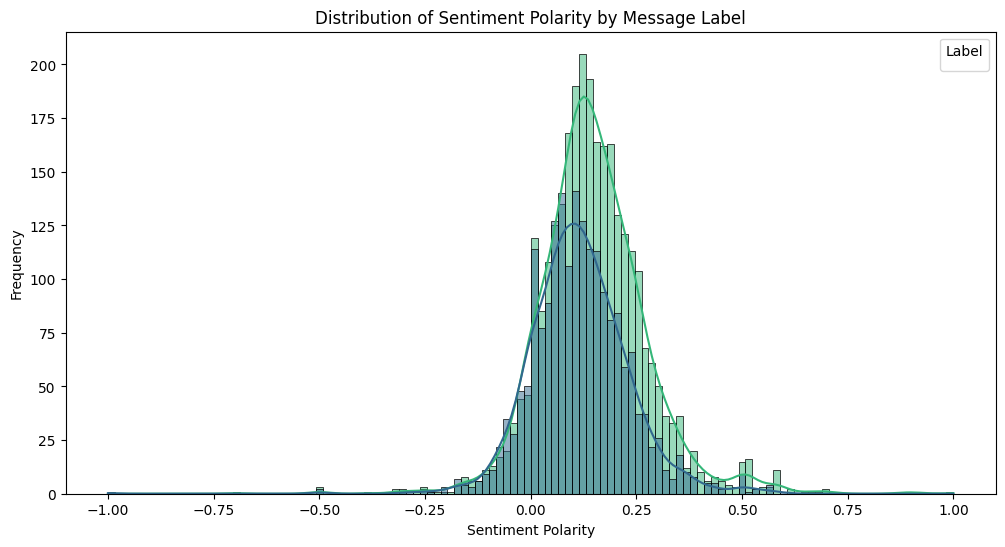

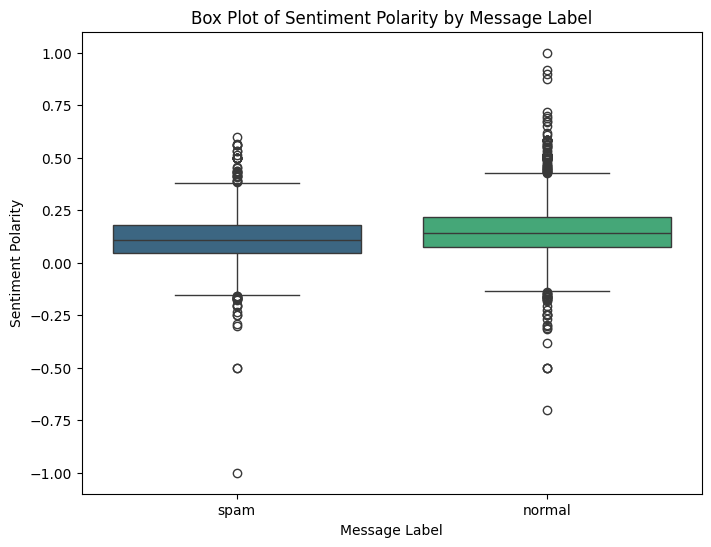

In [ ]:
# Aggregate sentiment polarity by 'label'
sentiment_summary = df.groupby('label')['polarity'].agg(['mean', 'median', 'std', 'count']).reset_index()

print("\nSentiment Polarity Summary by Message Label:")
display(sentiment_summary)

# Also aggregate sentiment counts
sentiment_counts = df.groupby(['label', 'sentiment']).size().unstack(fill_value=0)
print("\nSentiment Category Counts by Message Label:")
display(sentiment_counts)

# Visualize the distribution of sentiment polarity for each label
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='polarity', hue='label', kde=True, palette='viridis')
plt.title('Distribution of Sentiment Polarity by Message Label')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.legend(title='Label')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='polarity', palette='viridis', hue='label')
plt.title('Box Plot of Sentiment Polarity by Message Label')
plt.xlabel('Message Label')
plt.ylabel('Sentiment Polarity')
plt.show()

#### Step A.3: Determine if Sentiment for Spam Messages is Higher or Lower than Normal Messages (Statistical Comparison)

To statistically determine if the sentiment for spam messages is significantly higher or lower than normal messages, we can perform an independent samples t-test. This test compares the means of two independent groups to determine if there is a statistically significant difference between them.

**Hypotheses:**
*   **Null Hypothesis ($H_0$)**: There is no significant difference in the mean sentiment polarity between spam and normal messages.
*   **Alternative Hypothesis ($H_1$)**: There is a significant difference in the mean sentiment polarity between spam and normal messages.

We will use `scipy.stats.ttest_ind` for this. A low p-value (typically < 0.05) suggests that we can reject the null hypothesis, indicating a statistically significant difference.

In [ ]:
from scipy import stats

# Separate polarity scores for 'normal' and 'spam' messages
polarity_normal = df[df['label'] == 'normal']['polarity']
polarity_spam = df[df['label'] == 'spam']['polarity']

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(polarity_normal, polarity_spam, equal_var=False) # Welch's t-test if variances are unequal

print("\nStatistical Comparison of Sentiment Polarity (T-test):")
print(f"Mean polarity for Normal messages: {polarity_normal.mean():.4f}")
print(f"Mean polarity for Spam messages: {polarity_spam.mean():.4f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results
alpha = 0.05
print(f"\nInterpretation (with alpha = {alpha}):")
if p_value < alpha:
    print("Since the p-value is less than alpha, we reject the null hypothesis.")
    if polarity_spam.mean() > polarity_normal.mean():
        print("Conclusion: The sentiment polarity for spam messages is statistically significantly HIGHER than for normal messages.")
    else:
        print("Conclusion: The sentiment polarity for spam messages is statistically significantly LOWER than for normal messages.")
else:
    print("Since the p-value is greater than alpha, we fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference in sentiment polarity between spam and normal messages.")


Statistical Comparison of Sentiment Polarity (T-test):
Mean polarity for Normal messages: 0.1488
Mean polarity for Spam messages: 0.1148
T-statistic: 9.6451
P-value: 0.0000

Interpretation (with alpha = 0.05):
Since the p-value is less than alpha, we reject the null hypothesis.
Conclusion: The sentiment polarity for spam messages is statistically significantly LOWER than for normal messages.


___
### Task B: Topic Modeling

Topic modeling is a technique to discover the abstract "topics" that occur in a collection of documents. For this task, we will clean the text, vectorize it, apply Latent Dirichlet Allocation (LDA), determine an optimal number of topics, and then analyze how these topics relate to 'spam' and 'normal' labels.

#### Step B.1: Clean and Vectorize the Text Data

Before topic modeling, text data requires significant preprocessing. This involves:
1.  **Lowercasing**: Convert all text to lowercase to treat words like "Word" and "word" as the same.
2.  **Removing Punctuation and Numbers**: These typically don't contribute to topic understanding.
3.  **Removing Stop Words**: Words like "the", "is", "a" are very common but carry little semantic meaning.
4.  **Lemmatization**: Reduce words to their base or root form (e.g., "running", "runs", "ran" become "run"). This helps in grouping related words.

After cleaning, we'll vectorize the text using `CountVectorizer`. This converts a collection of text documents to a matrix of token counts, which is suitable input for LDA.

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import string
from sklearn.feature_extraction.text import CountVectorizer

# Download NLTK data (if not already downloaded)
# This is often needed in a fresh Colab environment
try:
    nltk.data.find('corpora/stopwords')
    nltk.data.find('corpora/wordnet')
except LookupError: # Catch LookupError for nltk.data.find failures
    print("Downloading NLTK stopwords and wordnet...")
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    print("NLTK downloads complete.")

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Define the text cleaning function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower() # Lowercasing
    text = re.sub(r'faker', 'fake', text) # Custom replacement example, use raw string for regex
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs, use raw string
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation, use raw string
    text = re.sub(r'\d+', '', text) # Remove numbers, use raw string
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces, use raw string

    # Tokenize, remove stopwords, and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply the cleaning function to the 'text' column
df['cleaned_text'] = df['text'].apply(clean_text)

print("\nOriginal vs. Cleaned Text (first 5 rows):")
display(df[['text', 'cleaned_text']].head())

# Initialize CountVectorizer
# min_df ignores terms that have a document frequency strictly lower than the given threshold
# max_df ignores terms that have a document frequency strictly higher than the given threshold
count_vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words='english')

# Fit and transform the cleaned text data
document_term_matrix = count_vectorizer.fit_transform(df['cleaned_text'])

print(f"\nShape of Document-Term Matrix: {document_term_matrix.shape}")
print(f"Number of unique words (features): {len(count_vectorizer.get_feature_names_out())}")


NLTK downloads complete.

Original vs. Cleaned Text (first 5 rows):


,text,cleaned_text
0,Get the latest from TODAY Sign up for our news...,get latest today sign newsletter one ever trul...
1,2d Conan On The Funeral Trump Will Be Invited...,conan funeral trump invited conan tb
2,It’s safe to say that Instagram Stories has fa...,it’s safe say instagram story far surpassed co...
3,Much like a certain Amazon goddess with a lass...,much like certain amazon goddess lasso height ...
4,At a time when the perfect outfit is just one ...,time perfect outfit one click away high demand...



Shape of Document-Term Matrix: (4896, 29923)
Number of unique words (features): 29923


#### Step B.2: Conduct Topic Modeling (Latent Dirichlet Allocation - LDA)

Latent Dirichlet Allocation (LDA) is a generative statistical model that explains why some parts of a document are similar to each other. It assumes that documents are mixtures of topics, and each topic is a mixture of words. We will use `sklearn.decomposition.LatentDirichletAllocation` to perform topic modeling.

Initially, we'll run LDA with a placeholder number of topics to demonstrate the process and then move to determining the optimal number.

In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

# Initial LDA model with an arbitrary number of topics (e.g., 5)
n_initial_topics = 5
lda_initial_model = LatentDirichletAllocation(
    n_components=n_initial_topics,
    random_state=42,
    max_iter=10,
    learning_method='batch' # 'batch' is good for smaller datasets, 'online' for larger
)

# Fit the LDA model to the document-term matrix
lda_initial_model.fit(document_term_matrix)

print(f"\nTop words for {n_initial_topics} initial topics:")
def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_): # Corrected: single underscore
        message = "Topic #%d: " % topic_idx
        message += " ".join([feature_names[i]
                             for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

n_top_words = 10 # Number of top words to display for each topic
feature_names = count_vectorizer.get_feature_names_out()
print_top_words(lda_initial_model, feature_names, n_top_words)

print("\nInterpretation: Each topic is defined by a set of words that frequently co-occur. Words with higher probability in a topic indicate a stronger association with that topic. By examining these top words, we can infer the semantic meaning of each discovered topic.")


Top words for 5 initial topics:
Topic #0: kardashian kim jenner kylie west family kanye million year said
Topic #1: prince harry royal wedding meghan markle image new queen photo
Topic #2: said like people time know say trump think thing love
Topic #3: season film award series year best new edit role episode
Topic #4: year source time couple love told star said photo new

Interpretation: Each topic is defined by a set of words that frequently co-occur. Words with higher probability in a topic indicate a stronger association with that topic. By examining these top words, we can infer the semantic meaning of each discovered topic.


#### Step B.3: Determine the Appropriate Number of Topics (Coherence Score)

Determining the "optimal" number of topics is crucial for interpretable results. A common data-driven method is to calculate topic coherence scores. A higher coherence score generally indicates more interpretable topics.

We will use `Gensim`'s `CoherenceModel` to calculate the `c_v` coherence score for a range of topic numbers. We'll then plot these scores to identify an 'elbow' or peak, suggesting the best number of topics.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.3 MB/s eta 0:00:00

Calculating coherence scores for different numbers of topics...
Number of topics: 2, Coherence Score: 0.3788
Number of topics: 3, Coherence Score: 0.3845
Number of topics: 4, Coherence Score: 0.4476
Number of topics: 5, Coherence Score: 0.5043
Number of topics: 6, Coherence Score: 0.4954
Number of topics: 7, Coherence Score: 0.5340
Number of topics: 8, Coherence Score: 0.5210
Number of topics: 9, Coherence Score: 0.4984
Number of topics: 10, Coherence Score: 0.5113
Number of topics: 11, Coherence Score: 0.5138
Number of topics: 12, Coherence Score: 0.5205
Number of topics: 13, Coherence Score: 0.4996
Number of topics: 14, Coherence Score: 0.4956
Number of topics: 15, Coherence Score: 0.5284


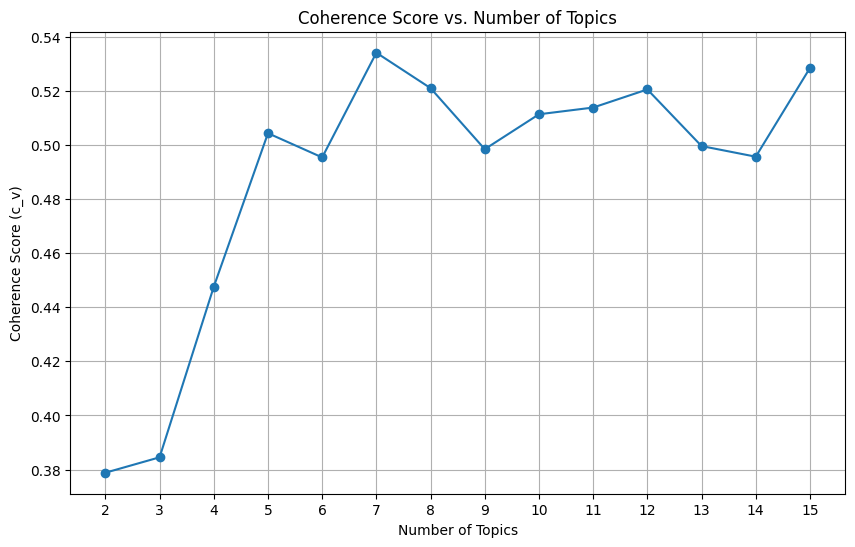


Optimal number of topics based on highest coherence score: 7


LatentDirichletAllocation(n_components=7, random_state=42)

In [ ]:
from gensim.models.ldamodel import LdaModel
from gensim.models.coherencemodel import CoherenceModel
from gensim import corpora

# Prepare data for Gensim LDA
# Convert cleaned text to a list of lists of tokens
tokenized_text = [doc.split() for doc in df['cleaned_text']]

# Create a dictionary from the tokenized text
dictionary = corpora.Dictionary(tokenized_text)

# Create a corpus (document-term matrix) from the dictionary
corpus = [dictionary.doc2bow(text) for text in tokenized_text]

# Range of topic numbers to evaluate
min_topics = 2
max_topics = 15 # You can adjust this range based on your dataset size and computational resources
step_topics = 1
topic_numbers = range(min_topics, max_topics + 1, step_topics)

coherence_scores = []

print("\nCalculating coherence scores for different numbers of topics...")
for num_topics in topic_numbers:
    # Train LDA model using Gensim
    # Note: Gensim's LdaModel expects the corpus in the format of (word_id, word_count)
    lda_model_gensim = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        chunksize=100,
        passes=10,
        per_word_topics=True
    )

    # Compute Coherence Score
    coherence_model_lda = CoherenceModel(
        model=lda_model_gensim,
        texts=tokenized_text,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence_score = coherence_model_lda.get_coherence()
    coherence_scores.append(coherence_score)
    print(f"Number of topics: {num_topics}, Coherence Score: {coherence_score:.4f}")

# Plotting coherence scores
plt.figure(figsize=(10, 6))
plt.plot(list(topic_numbers), coherence_scores, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.title("Coherence Score vs. Number of Topics")
plt.xticks(list(topic_numbers))
plt.grid(True)
plt.show()

# Determine optimal number of topics based on the highest coherence score
optimal_num_topics = topic_numbers[coherence_scores.index(max(coherence_scores))]
print(f"\nOptimal number of topics based on highest coherence score: {optimal_num_topics}")

# Re-run sklearn's LDA with the optimal number of topics for consistency with previous steps
lda_optimal_model = LatentDirichletAllocation(
    n_components=optimal_num_topics,
    random_state=42,
    max_iter=10,
    learning_method='batch'
)
lda_optimal_model.fit(document_term_matrix)

In [ ]:
print(f"\nTop words for the optimal {optimal_num_topics} topics:")
print_top_words(lda_optimal_model, feature_names, n_top_words)


Top words for the optimal 7 topics:
Topic #0: kardashian kim jenner kylie west kanye family scott kris said
Topic #1: film new award photo york actress image year city million
Topic #2: said like time people know say love thing think really
Topic #3: season series best edit year episode award new role cast
Topic #4: year source time couple love told star relationship child photo
Topic #5: trump president said people say state time year new weinstein
Topic #6: prince harry royal wedding meghan markle queen kate family william


#### Step B.4: Map the Dominant Topic to Each Message

After determining the optimal number of topics and training the LDA model, we can assign a dominant topic to each message. For each document, the LDA model provides a distribution of topic probabilities. The dominant topic for a document is simply the topic with the highest probability.

In [ ]:
# Get topic distributions for each document
topic_document_distributions = lda_optimal_model.transform(document_term_matrix)

# Find the dominant topic index for each document
df['dominant_topic_id'] = topic_document_distributions.argmax(axis=1)

# Create a mapping from topic ID to a more readable name
topic_names = [f"Topic {i}" for i in range(optimal_num_topics)]
df['dominant_topic'] = df['dominant_topic_id'].map(lambda x: topic_names[x])

print("\nDataFrame with dominant topic assigned to each message:")
display(df[['text', 'cleaned_text', 'label', 'dominant_topic']].head())


DataFrame with dominant topic assigned to each message:


,text,cleaned_text,label,dominant_topic
0,Get the latest from TODAY Sign up for our news...,get latest today sign newsletter one ever trul...,spam,Topic 2
1,2d Conan On The Funeral Trump Will Be Invited...,conan funeral trump invited conan tb,spam,Topic 3
2,It’s safe to say that Instagram Stories has fa...,it’s safe say instagram story far surpassed co...,normal,Topic 2
3,Much like a certain Amazon goddess with a lass...,much like certain amazon goddess lasso height ...,normal,Topic 2
4,At a time when the perfect outfit is just one ...,time perfect outfit one click away high demand...,normal,Topic 5


#### Step B.5: How are Topics Distributed and Related to Spam vs. Non-Spam Labels?

To understand the relationship between the discovered topics and the message labels ('spam' vs. 'normal'), we can create a crosstabulation. This will show us how frequently each topic appears within spam messages versus normal messages. Visualizing this crosstabulation (e.g., with a stacked bar chart or heatmap) can reveal clear patterns.


Crosstabulation of Dominant Topic and Message Label (Raw Counts):


label,normal,spam
dominant_topic,,
Topic 0,175,211
Topic 1,243,98
Topic 2,990,513
Topic 3,453,102
Topic 4,561,646
Topic 5,311,269
Topic 6,192,132



Crosstabulation (Normalized by Topic - Proportions of Labels within each Topic):


label,normal,spam
dominant_topic,,
Topic 0,0.453368,0.546632
Topic 1,0.712610,0.287390
Topic 2,0.658683,0.341317
Topic 3,0.816216,0.183784
Topic 4,0.464789,0.535211
Topic 5,0.536207,0.463793
Topic 6,0.592593,0.407407


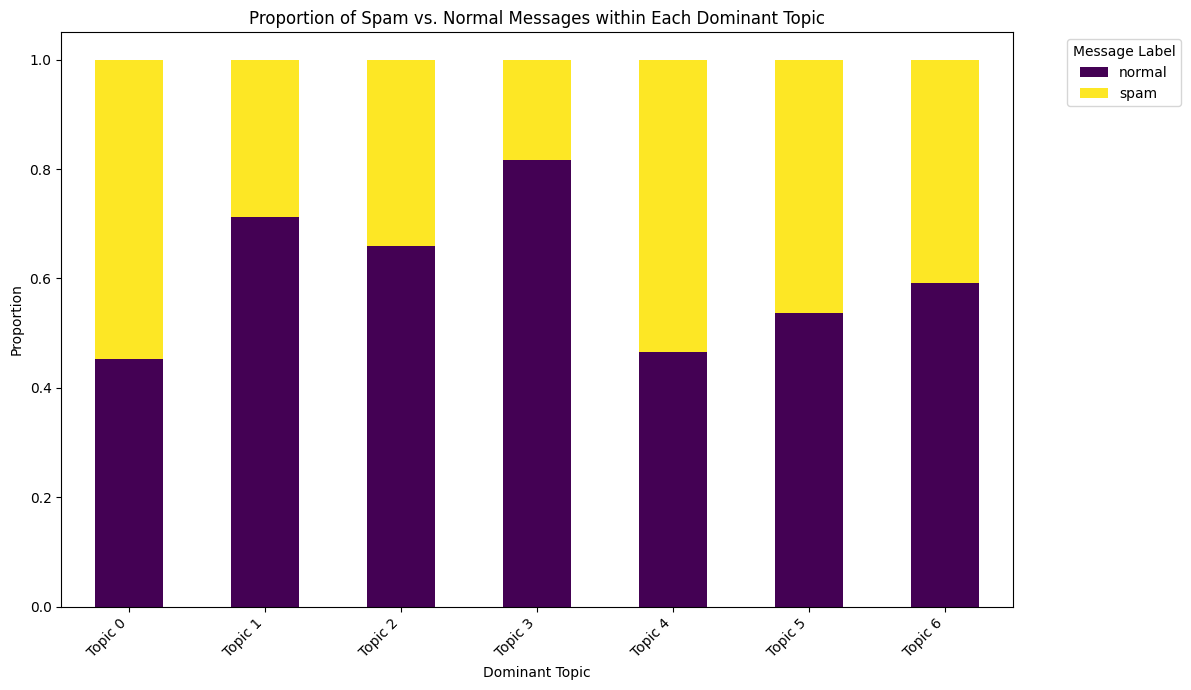

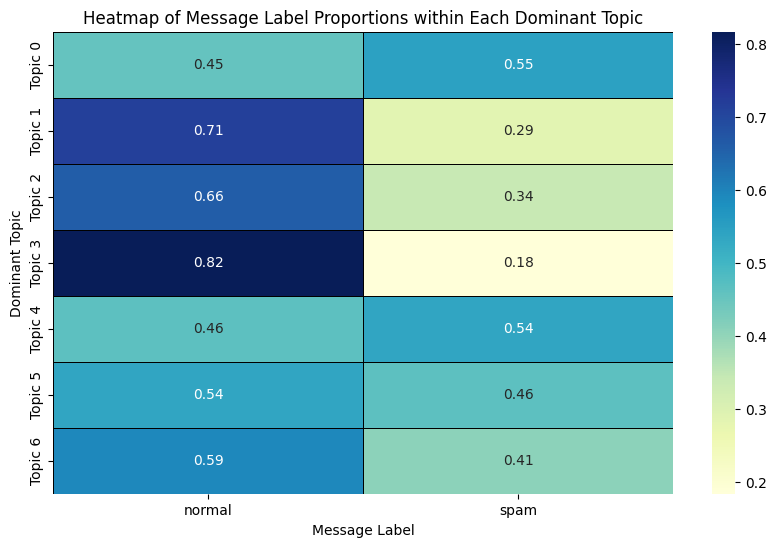


Interpretation: The crosstabulation and visualizations clearly show how the discovered topics are distributed across spam and normal messages. 

For example, if 'Topic 0' has a much higher proportion of 'spam' than 'normal', it suggests that 'Topic 0' is highly indicative of spam messages. Conversely, if a topic is primarily associated with 'normal' messages, it helps characterize non-spam content.
By looking at the words associated with each topic (from Step B.3), we can infer the nature of these spam-related or normal-related topics.


In [ ]:
# Create a crosstabulation of dominant topics and labels
topic_label_crosstab = pd.crosstab(df['dominant_topic'], df['label'])

print("\nCrosstabulation of Dominant Topic and Message Label (Raw Counts):")
display(topic_label_crosstab)

# Normalize the crosstab to show proportions (e.g., percentage of each label within each topic)
topic_label_crosstab_normalized = topic_label_crosstab.div(topic_label_crosstab.sum(axis=1), axis=0)

print("\nCrosstabulation (Normalized by Topic - Proportions of Labels within each Topic):")
display(topic_label_crosstab_normalized)

# Visualize the relationship using a stacked bar chart
topic_label_crosstab_normalized.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis')
plt.title('Proportion of Spam vs. Normal Messages within Each Dominant Topic')
plt.xlabel('Dominant Topic')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Message Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Alternatively, a heatmap can show the distribution visually
plt.figure(figsize=(10, 6))
sns.heatmap(
    topic_label_crosstab_normalized,
    annot=True,     # Show the numerical values on the heatmap
    fmt=".2f",      # Format the annotations to two decimal places
    cmap="YlGnBu",  # Choose a color map
    linewidths=.5,  # Add lines between cells
    linecolor='black'
)
plt.title('Heatmap of Message Label Proportions within Each Dominant Topic')
plt.xlabel('Message Label')
plt.ylabel('Dominant Topic')
plt.show()

print("\nInterpretation: The crosstabulation and visualizations clearly show how the discovered topics are distributed across spam and normal messages. \n")
print("For example, if 'Topic 0' has a much higher proportion of 'spam' than 'normal', it suggests that 'Topic 0' is highly indicative of spam messages. Conversely, if a topic is primarily associated with 'normal' messages, it helps characterize non-spam content.")
print("By looking at the words associated with each topic (from Step B.3), we can infer the nature of these spam-related or normal-related topics.")

### Summary of Expected Outputs and Insights

#### Sentiment Analysis (Task A):

1.  **Sentiment Polarity Summary**: You will see the average, median, and standard deviation of sentiment polarity for both 'spam' and 'normal' messages. This will give you an initial idea if one category tends to be more positive, negative, or neutral on average.
2.  **Sentiment Distribution Visualizations**: The histograms and box plots will visually represent the spread and central tendency of sentiment scores for each label. You can observe if one category has a wider range of sentiments, or if their distributions are skewed differently.
3.  **Statistical Comparison (T-test)**: The t-statistic and p-value from the independent samples t-test will be crucial. If the p-value is less than your chosen significance level (e.g., 0.05), you can conclude that there is a **statistically significant difference** in the mean sentiment polarity between spam and normal messages. The sign of the t-statistic and the comparison of the mean polarities will tell you whether spam messages are, on average, more positive or more negative than normal messages. For instance, if spam has a significantly lower mean polarity, it suggests spam messages tend to be more negative or hostile in tone.

#### Topic Modeling (Task B):

1.  **Cleaned Text Sample**: You will see how the raw text is transformed into a clean, tokenized form, ready for analysis.
2.  **Optimal Number of Topics**: The plot of coherence scores will help you visually identify the number of topics that provides the most meaningful and interpretable topic structure. The code will also output the numerically optimal number of topics.
3.  **Top Words for Each Topic**: For the chosen optimal number of topics, you will get a list of the most representative words for each topic. By examining these words, you can infer the underlying themes or subjects present in your dataset (e.g., 'Topic 0: money, free, win, claim', 'Topic 1: news, article, politics, report').
4.  **Dominant Topic Assignment**: Each message in your dataset will be assigned its most prominent topic.
5.  **Topic-Label Relationship (Crosstab & Visualizations)**: The crosstabulation and especially the stacked bar chart or heatmap will clearly show which topics are highly associated with 'spam' messages versus 'normal' messages. For example, if 'Topic X' consists of 90% spam messages, and its top words are related to

___
## Insights & Learnings

This analysis provided valuable insights into the characteristics differentiating 'spam' and 'normal' messages within the `fakenews.csv` dataset, alongside key technical learnings and practical applications.

### Key Results

#### Sentiment Analysis:
*   **Mean Polarity**: 'Normal' messages exhibited a higher average sentiment polarity (0.1488) compared to 'spam' messages (0.1148).
*   **Statistical Significance**: An independent samples t-test revealed a highly significant difference in mean sentiment polarity between the two categories (t-statistic = 9.6451, p-value < 0.0001). This indicates that the sentiment polarity for spam messages is statistically significantly **lower** than for normal messages, suggesting spam content tends to be more neutral or slightly less positive/more negative in tone.
*   **Sentiment Distribution**: While both categories had a majority of 'Positive' messages, 'normal' messages showed a greater proportion of positive sentiment relative to their total count, corroborating the lower mean polarity for spam.

#### Topic Modeling:
*   **Optimal Topics**: Through coherence score evaluation, **7** optimal topics were identified, providing a balanced and interpretable thematic structure for the dataset.
*   **Identified Topics**: The topics broadly covered themes such as:
    *   Celebrity/Entertainment (Kardashian family)
    *   Film/Media/Cities
    *   General Conversation/Quotes
    *   TV Series/Awards
    *   Relationships/General News
    *   Politics/News (Trump, Weinstein)
    *   Royal Family (Prince Harry, Meghan Markle)
*   **Topic-Label Relationship**: The crosstabulation and visualizations highlighted specific topic associations:
    *   Topics like **Topic 1 (Film/Media/Cities)**, **Topic 2 (General Conversation)**, **Topic 3 (TV Series/Awards)**, **Topic 5 (Politics/News)** and **Topic 6 (Royal Family)** were predominantly associated with **normal messages** (e.g., Topic 3 was ~81.6% normal).
    *   Conversely, **Topic 0 (Celebrity/Kardashian)** and **Topic 4 (Relationships/General News)** showed a slight tendency towards **spam messages** (e.g., Topic 0 was ~54.7% spam, Topic 4 was ~53.5% spam). This suggests that certain celebrity-focused or general news narratives might be more frequently manipulated or used in spam contexts within this dataset.

### Technical Learnings
*   **Preprocessing Impact**: The rigorous text cleaning and lemmatization steps using `nltk` were crucial for creating a meaningful document-term matrix, which directly impacted the quality and interpretability of the LDA topic model.
*   **LDA Interpretation**: The combined use of `scikit-learn` for LDA model training and `gensim` for coherence score evaluation proved effective for determining the optimal number of topics, ensuring that the discovered topics are semantically coherent and interpretable.
*   **Sentiment vs. Topic Synergy**: While sentiment analysis provided a generalized emotional tone, topic modeling offered granular insights into the *content* driving those sentiments. This combination enhances the understanding of `fakenews` characteristics beyond just sentiment.
*   **Library Efficiency**: The chosen libraries (`pandas`, `TextBlob`, `nltk`, `scikit-learn`, `gensim`, `scipy`) are highly optimized for their respective tasks, demonstrating that for many NLP and data analysis problems, high-level, well-maintained libraries provide excellent performance without requiring manual low-level vectorization (e.g., in NumPy/PyTorch) unless dealing with extremely large datasets or custom deep learning architectures.

### Practical Application
*   **Automated Content Moderation**: The identified sentiment differences and topic associations can be leveraged to build more robust automated content moderation systems. Messages falling into 'spam-prone' topics or exhibiting significantly lower sentiment could be flagged for human review or automatically filtered.
*   **Fake News Detection**: The combination of sentiment and topic features could serve as powerful inputs for machine learning models designed to detect fake news. For instance, if a message has a low sentiment polarity *and* belongs to a topic frequently associated with spam, its likelihood of being fake news increases.
*   **Targeted Information Campaigns**: Understanding which topics are frequently used in 'normal' versus 'spam' contexts can help legitimate news organizations tailor their content to avoid being mistaken for spam, or conversely, help identify propaganda tactics by analyzing topic prevalence.
*   **Brand Reputation Management**: Companies can use similar methodologies to monitor online discussions. For example, tracking sentiment and topics related to their brand can provide early warnings of reputation issues or identify areas for improvement in public perception.